# Notebook 01c — Dataset Evaluation (Augmented)
**FracAtlas YOLOv8s Fracture Detection Pipeline**

Evaluates the quality and readiness of the augmented hand dataset before training.

## What This Notebook Does:
1. ✅ **Dataset Overview** - Statistics per split, comparison with original dataset
2. ✅ **Label Quality Check** - Validate format, detect corrupt/missing labels, bbox statistics
3. ✅ **Image Quality Check** - Detect corrupt images, size distribution, aspect ratio analysis
4. ✅ **Visualize Samples** - Original vs augmented pairs, fractured/non-fractured examples
5. ✅ **Augmentation Effectiveness** - Did augmentation create meaningful variation?
6. ✅ **Summary & Recommendations** - Go/No-Go for training

> **Run this AFTER Notebook 01b (Hand Augmentation) and BEFORE Notebook 02 (Training).**

## 1. Setup & Configuration

In [1]:
import os
import cv2
import yaml
import random
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [2]:
# ─── PATHS ────────────────────────────────────────────────────────────────────
BASE_DIR = Path.cwd().parent  # Go up one level from notebooks/

# Augmented dataset paths
AUGMENTED_DATASET_DIR = BASE_DIR / "yolo_dataset_hand_augmented"
AUGMENTED_YAML = BASE_DIR / "fracatlas_hand_augmented.yaml"

# Original dataset paths (for comparison)
ORIGINAL_DATASET_DIR = BASE_DIR / "yolo_dataset"
ORIGINAL_YAML = BASE_DIR / "datasets" / "fracatlas.yaml"

print("=" * 70)
print("DATASET EVALUATION CONFIGURATION")
print("=" * 70)
print(f"\nAugmented dataset: {AUGMENTED_DATASET_DIR.resolve()}")
print(f"Augmented YAML:      {AUGMENTED_YAML.resolve()}")
print(f"Original dataset:    {ORIGINAL_DATASET_DIR.resolve()}")
print(f"Original YAML:       {ORIGINAL_YAML.resolve()}")

# Load YAML configs
if AUGMENTED_YAML.exists():
    with open(AUGMENTED_YAML) as f:
        aug_config = yaml.safe_load(f)
    print(f"\n✓ Augmented config loaded: {aug_config['nc']} class(es)")
else:
    print(f"\n⚠️  Augmented YAML not found at {AUGMENTED_YAML}")
    aug_config = None

if ORIGINAL_YAML.exists():
    with open(ORIGINAL_YAML) as f:
        orig_config = yaml.safe_load(f)
    print(f"✓ Original config loaded")
else:
    print(f"⚠️  Original YAML not found at {ORIGINAL_YAML}")
    orig_config = None

DATASET EVALUATION CONFIGURATION

Augmented dataset: D:\Project Medical Object Detection\FracAtlas\yolo_dataset_hand_augmented
Augmented YAML:      D:\Project Medical Object Detection\FracAtlas\fracatlas_hand_augmented.yaml
Original dataset:    D:\Project Medical Object Detection\FracAtlas\yolo_dataset
Original YAML:       D:\Project Medical Object Detection\FracAtlas\datasets\fracatlas.yaml

✓ Augmented config loaded: 1 class(es)
✓ Original config loaded


## 2. Dataset Overview & Comparison

In [3]:
def get_dataset_stats(dataset_dir: Path, dataset_name: str = "Dataset"):
    """Get comprehensive dataset statistics."""
    stats = {'name': dataset_name, 'splits': {}}
    
    for split in ['train', 'val', 'test']:
        img_dir = dataset_dir / 'images' / split
        label_dir = dataset_dir / 'labels' / split
        
        if not img_dir.exists():
            continue
        
        # Get all images
        all_extensions = ['*.jpg', '*.jpeg', '*.png']
        images = []
        for ext in all_extensions:
            images.extend(list(img_dir.glob(ext)))
        
        n_images = len(images)
        n_fractured = 0
        n_non_fractured = 0
        n_labels_with_bbox = 0
        total_bboxes = 0
        
        for img in images:
            label_path = label_dir / f"{img.stem}.txt"
            if label_path.exists() and label_path.stat().st_size > 0:
                n_fractured += 1
                # Count bboxes
                with open(label_path, 'r') as f:
                    lines = [l for l in f.readlines() if l.strip()]
                    total_bboxes += len(lines)
                    if len(lines) > 0:
                        n_labels_with_bbox += 1
            else:
                n_non_fractured += 1
        
        stats['splits'][split] = {
            'n_images': n_images,
            'n_fractured': n_fractured,
            'n_non_fractured': n_non_fractured,
            'n_labels_with_bbox': n_labels_with_bbox,
            'total_bboxes': total_bboxes,
            'avg_bboxes_per_frac_img': total_bboxes / n_fractured if n_fractured > 0 else 0
        }
    
    return stats


# Get statistics for both datasets
print("Computing dataset statistics...")
aug_stats = get_dataset_stats(AUGMENTED_DATASET_DIR, "Augmented")

if ORIGINAL_DATASET_DIR.exists():
    orig_stats = get_dataset_stats(ORIGINAL_DATASET_DIR, "Original")
    has_original = True
else:
    orig_stats = None
    has_original = False
    print("⚠️  Original dataset not found, skipping comparison")

# Display comprehensive summary
print("\n" + "=" * 90)
print("DATASET OVERVIEW - AUGMENTED")
print("=" * 90)

total_images = 0
total_fractured = 0
total_non_fractured = 0
total_bboxes = 0

print(f"{'Split':<10} | {'Images':<8} | {'Fractured':<12} | {'Non-Frac':<12} | {'BBoxes':<10} | {'Avg BBox/Frac':<15}")
print("-" * 90)

for split in ['train', 'val', 'test']:
    if split not in aug_stats['splits']:
        continue
    
    s = aug_stats['splits'][split]
    total_images += s['n_images']
    total_fractured += s['n_fractured']
    total_non_fractured += s['n_non_fractured']
    total_bboxes += s['total_bboxes']
    
    print(f"{split.capitalize():<10} | {s['n_images']:<8} | {s['n_fractured']:<12} | {s['n_non_fractured']:<12} | {s['total_bboxes']:<10} | {s['avg_bboxes_per_frac_img']:<15.2f}")

print("-" * 90)
print(f"{'TOTAL':<10} | {total_images:<8} | {total_fractured:<12} | {total_non_fractured:<12} | {total_bboxes:<10}")
print(f"\nFracture Rate: {100*total_fractured/total_images:.1f}%")
print(f"Non-Fracture Rate: {100*total_non_fractured/total_images:.1f}%")
print(f"Ratio (Non-Frac / Frac): {total_non_fractured/total_fractured:.2f}:1")

# Comparison with original
if has_original and orig_stats:
    print("\n" + "=" * 90)
    print("COMPARISON: AUGMENTED vs ORIGINAL")
    print("=" * 90)
    
    print(f"\n{'Metric':<30} | {'Original':<12} | {'Augmented':<12} | {'Change':<15}")
    print("-" * 90)
    
    for split in ['train', 'val', 'test', 'total']:
        if split == 'total':
            orig_total = sum(s['n_images'] for s in orig_stats['splits'].values())
            aug_total = total_images
            orig_name = f"Original Total"
            aug_name = f"Augmented Total"
            change = ((aug_total - orig_total) / orig_total * 100) if orig_total > 0 else 0
            print(f"{orig_name:<30} | {orig_total:<12} | {aug_total:<12} | {change:+.1f}%")
        else:
            if split in orig_stats['splits'] and split in aug_stats['splits']:
                orig_n = orig_stats['splits'][split]['n_images']
                aug_n = aug_stats['splits'][split]['n_images']
                change = ((aug_n - orig_n) / orig_n * 100) if orig_n > 0 else 0
                print(f"{split.capitalize() + ' images':<30} | {orig_n:<12} | {aug_n:<12} | {change:+.1f}%")

Computing dataset statistics...

DATASET OVERVIEW - AUGMENTED
Split      | Images   | Fractured    | Non-Frac     | BBoxes     | Avg BBox/Frac  
------------------------------------------------------------------------------------------
Train      | 2153     | 613          | 1540         | 755        | 1.23           
Val        | 461      | 131          | 330          | 163        | 1.24           
Test       | 462      | 132          | 330          | 180        | 1.36           
------------------------------------------------------------------------------------------
TOTAL      | 3076     | 876          | 2200         | 1098      

Fracture Rate: 28.5%
Non-Fracture Rate: 71.5%
Ratio (Non-Frac / Frac): 2.51:1

COMPARISON: AUGMENTED vs ORIGINAL

Metric                         | Original     | Augmented    | Change         
------------------------------------------------------------------------------------------
Train images                   | 645          | 2153         | +233.8%
Val

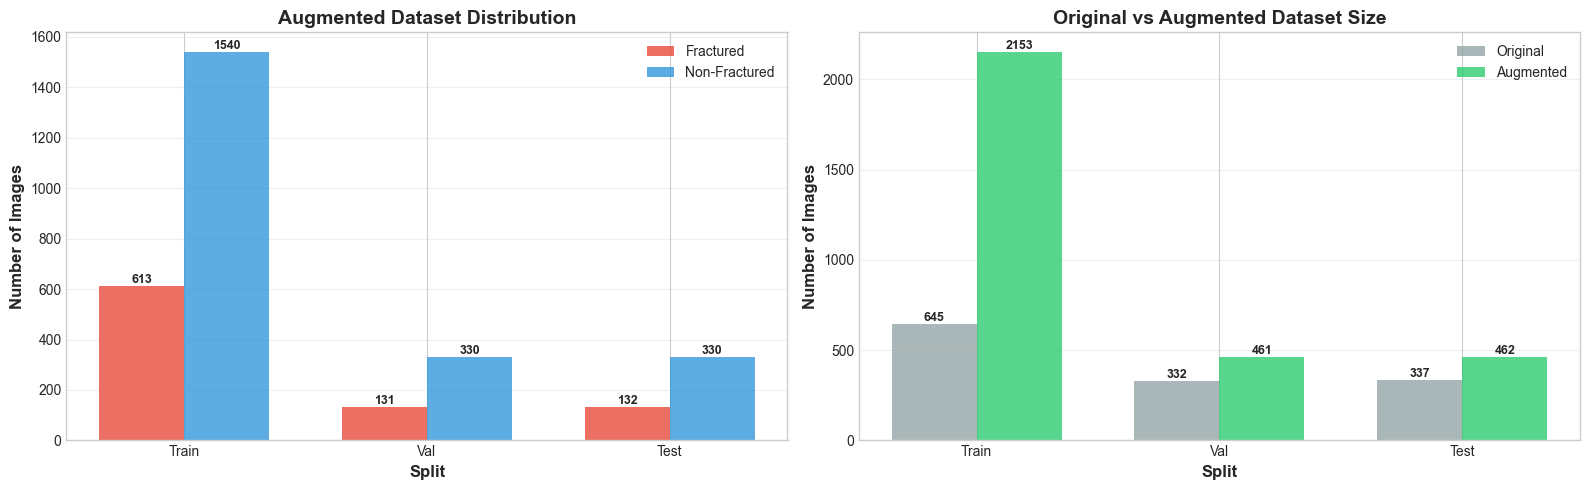


✓ Plot saved to: d:\Project Medical Object Detection\FracAtlas\dataset_distribution_comparison.png


In [4]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Augmented dataset distribution
splits = list(aug_stats['splits'].keys())
frac_counts = [aug_stats['splits'][s]['n_fractured'] for s in splits]
non_frac_counts = [aug_stats['splits'][s]['n_non_fractured'] for s in splits]

x = np.arange(len(splits))
width = 0.35

bars1 = axes[0].bar(x - width/2, frac_counts, width, label='Fractured', color='#e74c3c', alpha=0.8)
bars2 = axes[0].bar(x + width/2, non_frac_counts, width, label='Non-Fractured', color='#3498db', alpha=0.8)

axes[0].set_xlabel('Split', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=12, fontweight='bold')
axes[0].set_title('Augmented Dataset Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([s.capitalize() for s in splits])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Comparison with original
if has_original and orig_stats:
    orig_splits = list(orig_stats['splits'].keys())
    orig_totals = [orig_stats['splits'][s]['n_images'] for s in orig_splits]
    aug_totals = [aug_stats['splits'][s]['n_images'] for s in splits]
    
    x2 = np.arange(len(splits))
    bars3 = axes[1].bar(x2 - width/2, orig_totals, width, label='Original', color='#95a5a6', alpha=0.8)
    bars4 = axes[1].bar(x2 + width/2, aug_totals, width, label='Augmented', color='#2ecc71', alpha=0.8)
    
    axes[1].set_xlabel('Split', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Number of Images', fontsize=12, fontweight='bold')
    axes[1].set_title('Original vs Augmented Dataset Size', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels([s.capitalize() for s in splits])
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    
    for bars in [bars3, bars4]:
        for bar in bars:
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Original dataset\nnot available', 
                ha='center', va='center', fontsize=14, alpha=0.5)
    axes[1].set_title('Original vs Augmented (N/A)', fontsize=14, fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(BASE_DIR / 'dataset_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Plot saved to: {BASE_DIR / 'dataset_distribution_comparison.png'}")

## 3. Label Quality Check

In [5]:
def validate_labels(label_dir: Path, split_name: str = ""):
    """Validate all label files in a directory."""
    issues = {
        'missing_labels': [],
        'empty_labels': [],
        'invalid_format': [],
        'invalid_bbox': [],
        'corrupt_files': []
    }
    
    img_dir = label_dir.parent.parent / 'images' / split_name
    all_extensions = ['*.jpg', '*.jpeg', '*.png']
    images = []
    for ext in all_extensions:
        images.extend(list(img_dir.glob(ext)))
    
    bbox_stats = []
    
    for img_path in tqdm(images, desc=f"Validating {split_name} labels", leave=False):
        label_path = label_dir / f"{img_path.stem}.txt"
        
        # Check if label exists
        if not label_path.exists():
            issues['missing_labels'].append(img_path.name)
            continue
        
        # Check if empty (non-fractured image)
        if label_path.stat().st_size == 0:
            issues['empty_labels'].append(img_path.name)
            continue
        
        # Validate format
        try:
            with open(label_path, 'r') as f:
                lines = [l.strip() for l in f.readlines() if l.strip()]
            
            for line_num, line in enumerate(lines, 1):
                parts = line.split()
                
                # Must have 5 values: class cx cy w h
                if len(parts) != 5:
                    issues['invalid_format'].append((img_path.name, line_num, line))
                    continue
                
                # Parse values
                try:
                    cls_id, cx, cy, w, h = map(float, parts)
                except ValueError:
                    issues['invalid_format'].append((img_path.name, line_num, line))
                    continue
                
                # Validate bbox values
                if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                    issues['invalid_bbox'].append((img_path.name, line_num, f"Values out of [0,1]: {line}"))
                
                # Check for very small bboxes (might be annotation error)
                if w * h < 0.0001:  # Less than 0.01% of image area
                    bbox_stats.append({'img': img_path.name, 'area': w*h, 'status': 'tiny'})
                else:
                    bbox_stats.append({'img': img_path.name, 'area': w*h, 'status': 'normal'})
        
        except Exception as e:
            issues['corrupt_files'].append((img_path.name, str(e)))
    
    return issues, bbox_stats


# Run validation on all splits
print("=" * 70)
print("LABEL QUALITY CHECK")
print("=" * 70)

all_issues = {}
all_bbox_stats = []

for split in ['train', 'val', 'test']:
    label_dir = AUGMENTED_DATASET_DIR / 'labels' / split
    if not label_dir.exists():
        print(f"\n⚠️  {split} label directory not found, skipping")
        continue
    
    issues, bbox_stats = validate_labels(label_dir, split)
    all_issues[split] = issues
    all_bbox_stats.extend(bbox_stats)
    
    print(f"\n{split.upper()} SPLIT:")
    print(f"  Missing labels:      {len(issues['missing_labels'])}")
    print(f"  Empty labels:        {len(issues['empty_labels'])} (non-fractured images)")
    print(f"  Invalid format:      {len(issues['invalid_format'])}")
    print(f"  Invalid bbox:        {len(issues['invalid_bbox'])}")
    print(f"  Corrupt files:       {len(issues['corrupt_files'])}")
    
    if issues['invalid_format']:
        print(f"\n  ⚠️  Sample invalid format issues:")
        for item in issues['invalid_format'][:3]:
            print(f"    - {item[0]}, line {item[1]}: {item[2]}")
    
    if issues['invalid_bbox']:
        print(f"\n  ⚠️  Sample invalid bbox issues:")
        for item in issues['invalid_bbox'][:3]:
            print(f"    - {item[0]}, line {item[1]}: {item[2]}")

# Summary
total_issues = sum(len(issues['missing_labels']) + len(issues['invalid_format']) + 
                   len(issues['invalid_bbox']) + len(issues['corrupt_files']) 
                   for issues in all_issues.values())

print("\n" + "=" * 70)
if total_issues == 0:
    print("✅ ALL LABELS ARE VALID - No critical issues found")
else:
    print(f"⚠️  TOTAL ISSUES FOUND: {total_issues}")
    print("Review the issues above before proceeding to training")

LABEL QUALITY CHECK



TRAIN SPLIT:
  Missing labels:      0
  Empty labels:        1540 (non-fractured images)
  Invalid format:      0
  Invalid bbox:        0
  Corrupt files:       0



VAL SPLIT:
  Missing labels:      0
  Empty labels:        330 (non-fractured images)
  Invalid format:      0
  Invalid bbox:        0
  Corrupt files:       0



TEST SPLIT:
  Missing labels:      0
  Empty labels:        330 (non-fractured images)
  Invalid format:      0
  Invalid bbox:        0
  Corrupt files:       0

✅ ALL LABELS ARE VALID - No critical issues found



BOUNDING BOX STATISTICS
Total bounding boxes: 1098

Area Distribution (relative to image):
  Min:    0.000645 (0.0645%)
  Max:    0.030861 (3.0861%)
  Mean:   0.004502 (0.4502%)
  Median: 0.003366 (0.3366%)
  Std:    0.003752


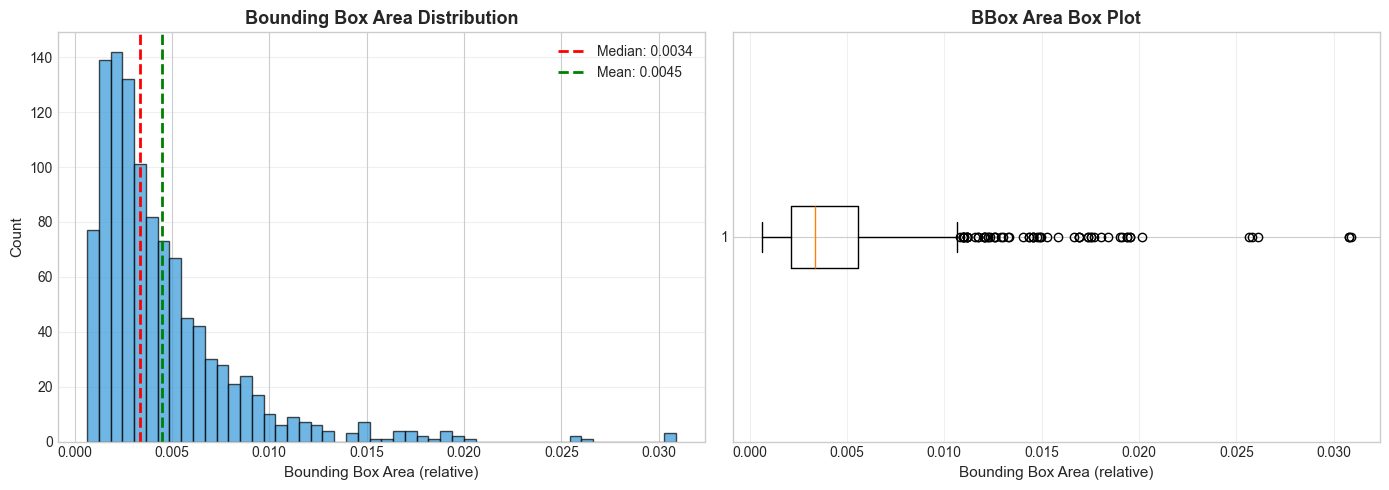


✓ Plot saved to: d:\Project Medical Object Detection\FracAtlas\bbox_area_distribution.png


In [6]:
# Bounding box statistics
if len(all_bbox_stats) > 0:
    print("\n" + "=" * 70)
    print("BOUNDING BOX STATISTICS")
    print("=" * 70)
    
    areas = [s['area'] for s in all_bbox_stats]
    areas_np = np.array(areas)
    
    print(f"Total bounding boxes: {len(areas)}")
    print(f"\nArea Distribution (relative to image):")
    print(f"  Min:    {areas_np.min():.6f} ({100*areas_np.min():.4f}%)")
    print(f"  Max:    {areas_np.max():.6f} ({100*areas_np.max():.4f}%)")
    print(f"  Mean:   {areas_np.mean():.6f} ({100*areas_np.mean():.4f}%)")
    print(f"  Median: {np.median(areas_np):.6f} ({100*np.median(areas_np):.4f}%)")
    print(f"  Std:    {areas_np.std():.6f}")
    
    # Tiny bboxes
    tiny_bboxes = [s for s in all_bbox_stats if s['status'] == 'tiny']
    if len(tiny_bboxes) > 0:
        print(f"\n⚠️  Tiny bboxes detected: {len(tiny_bboxes)}")
        print("These might be annotation errors:")
        for item in tiny_bboxes[:5]:
            print(f"    - {item['img']}: area={item['area']:.6f}")
    
    # Visualize bbox area distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(areas, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
    axes[0].axvline(np.median(areas), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(areas):.4f}')
    axes[0].axvline(np.mean(areas), color='green', linestyle='--', linewidth=2, label=f'Mean: {np.mean(areas):.4f}')
    axes[0].set_xlabel('Bounding Box Area (relative)', fontsize=11)
    axes[0].set_ylabel('Count', fontsize=11)
    axes[0].set_title('Bounding Box Area Distribution', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Box plot
    axes[1].boxplot(areas, vert=False)
    axes[1].set_xlabel('Bounding Box Area (relative)', fontsize=11)
    axes[1].set_title('BBox Area Box Plot', fontsize=13, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'bbox_area_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Plot saved to: {BASE_DIR / 'bbox_area_distribution.png'}")
else:
    print("\n⚠️  No bounding boxes found in dataset")

## 4. Image Quality Check

In [7]:
def validate_images(img_dir: Path, split_name: str = ""):
    """Validate all image files in a directory."""
    issues = {
        'corrupt': [],
        'grayscale': [],
        'very_small': [],
        'very_large': [],
    }
    
    image_stats = []
    all_extensions = ['*.jpg', '*.jpeg', '*.png']
    images = []
    for ext in all_extensions:
        images.extend(list(img_dir.glob(ext)))
    
    for img_path in tqdm(images, desc=f"Checking {split_name} images", leave=False):
        try:
            # Try to open with PIL
            img = Image.open(img_path)
            img.verify()
            img = Image.open(img_path)  # Re-open after verify
            
            w, h = img.size
            
            # Check if grayscale
            if img.mode == 'L':
                issues['grayscale'].append(img_path.name)
            
            # Check dimensions
            if w < 100 or h < 100:
                issues['very_small'].append((img_path.name, w, h))
            
            if w > 4000 or h > 4000:
                issues['very_large'].append((img_path.name, w, h))
            
            image_stats.append({
                'name': img_path.name,
                'width': w,
                'height': h,
                'aspect_ratio': w / h,
                'area': w * h,
                'mode': img.mode
            })
        
        except Exception as e:
            issues['corrupt'].append((img_path.name, str(e)))
    
    return issues, image_stats


# Run validation on all splits
print("=" * 70)
print("IMAGE QUALITY CHECK")
print("=" * 70)

all_img_issues = {}
all_img_stats = []

for split in ['train', 'val', 'test']:
    img_dir = AUGMENTED_DATASET_DIR / 'images' / split
    if not img_dir.exists():
        print(f"\n⚠️  {split} image directory not found, skipping")
        continue
    
    issues, img_stats = validate_images(img_dir, split)
    all_img_issues[split] = issues
    all_img_stats.extend(img_stats)
    
    print(f"\n{split.upper()} SPLIT:")
    print(f"  Corrupt images:      {len(issues['corrupt'])}")
    print(f"  Grayscale:           {len(issues['grayscale'])}")
    print(f"  Very small (<100px): {len(issues['very_small'])}")
    print(f"  Very large (>4000px):{len(issues['very_large'])}")
    
    if issues['corrupt']:
        print(f"\n  ⚠️  Corrupt images:")
        for item in issues['corrupt'][:5]:
            print(f"    - {item[0]}: {item[1]}")

# Summary
total_corrupt = sum(len(issues['corrupt']) for issues in all_img_issues.values())
print("\n" + "=" * 70)
if total_corrupt == 0:
    print("✅ ALL IMAGES ARE VALID - No corrupt images found")
else:
    print(f"⚠️  CORRUPT IMAGES FOUND: {total_corrupt}")
    print("These images should be removed or replaced before training")

IMAGE QUALITY CHECK



TRAIN SPLIT:
  Corrupt images:      0
  Grayscale:           0
  Very small (<100px): 0
  Very large (>4000px):0



VAL SPLIT:
  Corrupt images:      0
  Grayscale:           0
  Very small (<100px): 0
  Very large (>4000px):0



TEST SPLIT:
  Corrupt images:      0
  Grayscale:           0
  Very small (<100px): 0
  Very large (>4000px):0

✅ ALL IMAGES ARE VALID - No corrupt images found



IMAGE SIZE STATISTICS

Width:
  Min:    373 px
  Max:    2880 px
  Mean:   554.6 px
  Median: 373.0 px

Height:
  Min:    214 px
  Max:    2880 px
  Mean:   615.0 px
  Median: 454.0 px

Aspect Ratio (W/H):
  Min:    0.800
  Max:    1.743
  Mean:   0.930
  Median: 0.822


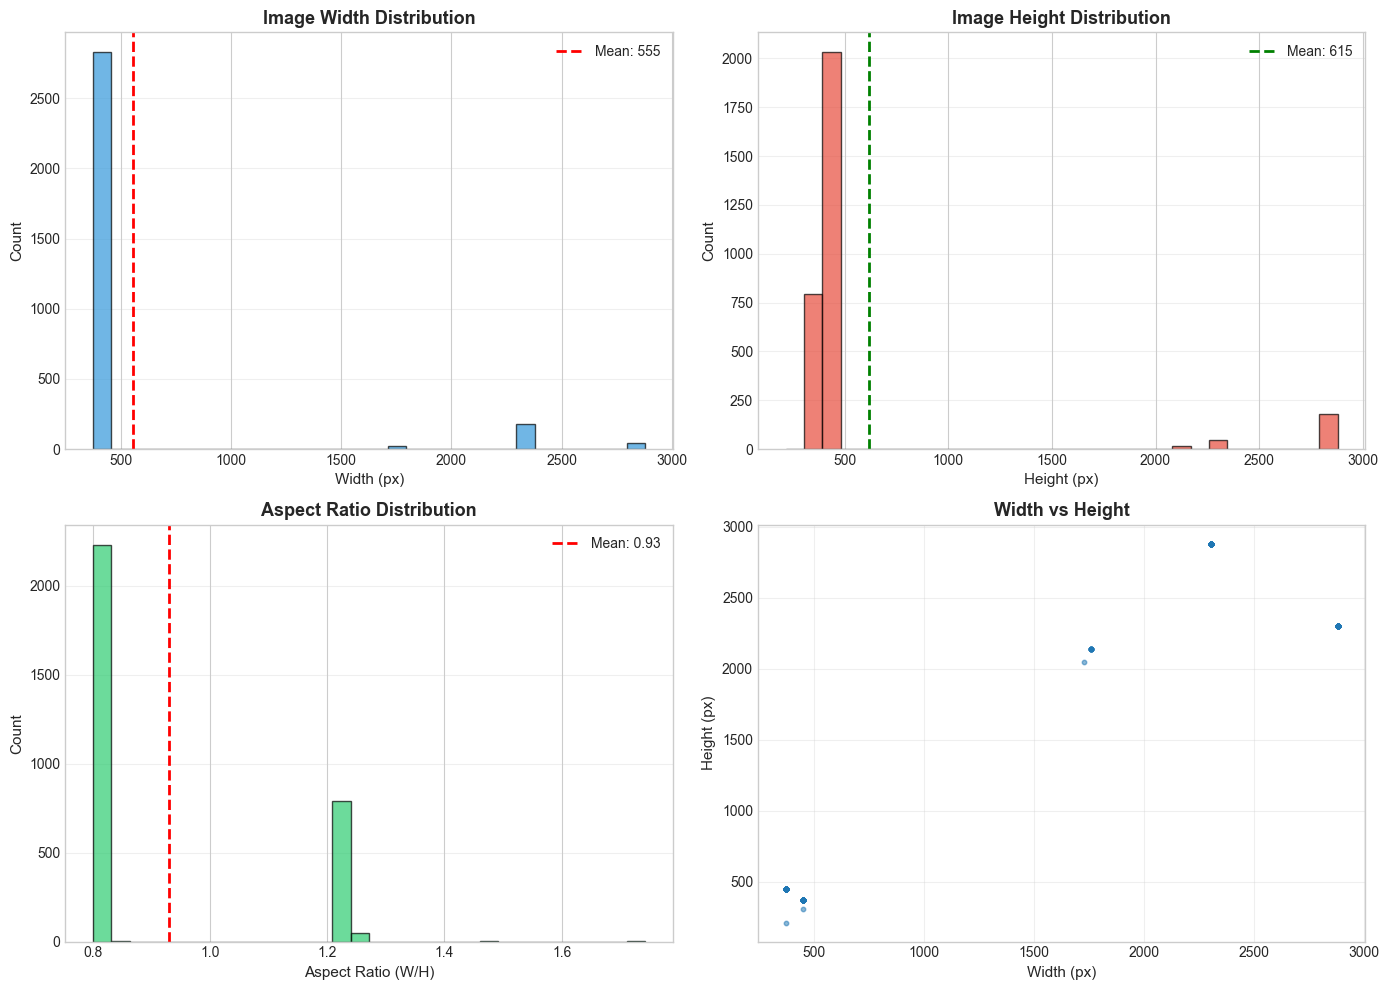


✓ Plot saved to: d:\Project Medical Object Detection\FracAtlas\image_size_distribution.png


In [8]:
# Image size distribution
if len(all_img_stats) > 0:
    df_imgs = pd.DataFrame(all_img_stats)
    
    print("\n" + "=" * 70)
    print("IMAGE SIZE STATISTICS")
    print("=" * 70)
    
    print(f"\nWidth:")
    print(f"  Min:    {df_imgs['width'].min()} px")
    print(f"  Max:    {df_imgs['width'].max()} px")
    print(f"  Mean:   {df_imgs['width'].mean():.1f} px")
    print(f"  Median: {df_imgs['width'].median():.1f} px")
    
    print(f"\nHeight:")
    print(f"  Min:    {df_imgs['height'].min()} px")
    print(f"  Max:    {df_imgs['height'].max()} px")
    print(f"  Mean:   {df_imgs['height'].mean():.1f} px")
    print(f"  Median: {df_imgs['height'].median():.1f} px")
    
    print(f"\nAspect Ratio (W/H):")
    print(f"  Min:    {df_imgs['aspect_ratio'].min():.3f}")
    print(f"  Max:    {df_imgs['aspect_ratio'].max():.3f}")
    print(f"  Mean:   {df_imgs['aspect_ratio'].mean():.3f}")
    print(f"  Median: {df_imgs['aspect_ratio'].median():.3f}")
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Width distribution
    axes[0, 0].hist(df_imgs['width'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(df_imgs['width'].mean(), color='red', linestyle='--', linewidth=2, 
                       label=f"Mean: {df_imgs['width'].mean():.0f}")
    axes[0, 0].set_xlabel('Width (px)', fontsize=11)
    axes[0, 0].set_ylabel('Count', fontsize=11)
    axes[0, 0].set_title('Image Width Distribution', fontsize=13, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # Height distribution
    axes[0, 1].hist(df_imgs['height'], bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
    axes[0, 1].axvline(df_imgs['height'].mean(), color='green', linestyle='--', linewidth=2,
                       label=f"Mean: {df_imgs['height'].mean():.0f}")
    axes[0, 1].set_xlabel('Height (px)', fontsize=11)
    axes[0, 1].set_ylabel('Count', fontsize=11)
    axes[0, 1].set_title('Image Height Distribution', fontsize=13, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Aspect ratio
    axes[1, 0].hist(df_imgs['aspect_ratio'], bins=30, color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(df_imgs['aspect_ratio'].mean(), color='red', linestyle='--', linewidth=2,
                       label=f"Mean: {df_imgs['aspect_ratio'].mean():.2f}")
    axes[1, 0].set_xlabel('Aspect Ratio (W/H)', fontsize=11)
    axes[1, 0].set_ylabel('Count', fontsize=11)
    axes[1, 0].set_title('Aspect Ratio Distribution', fontsize=13, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # Scatter plot (width vs height)
    axes[1, 1].scatter(df_imgs['width'], df_imgs['height'], alpha=0.3, s=10)
    axes[1, 1].set_xlabel('Width (px)', fontsize=11)
    axes[1, 1].set_ylabel('Height (px)', fontsize=11)
    axes[1, 1].set_title('Width vs Height', fontsize=13, fontweight='bold')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'image_size_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Plot saved to: {BASE_DIR / 'image_size_distribution.png'}")

## 5. Visualize Sample Images

VISUALIZING AUGMENTED IMAGE PAIRS


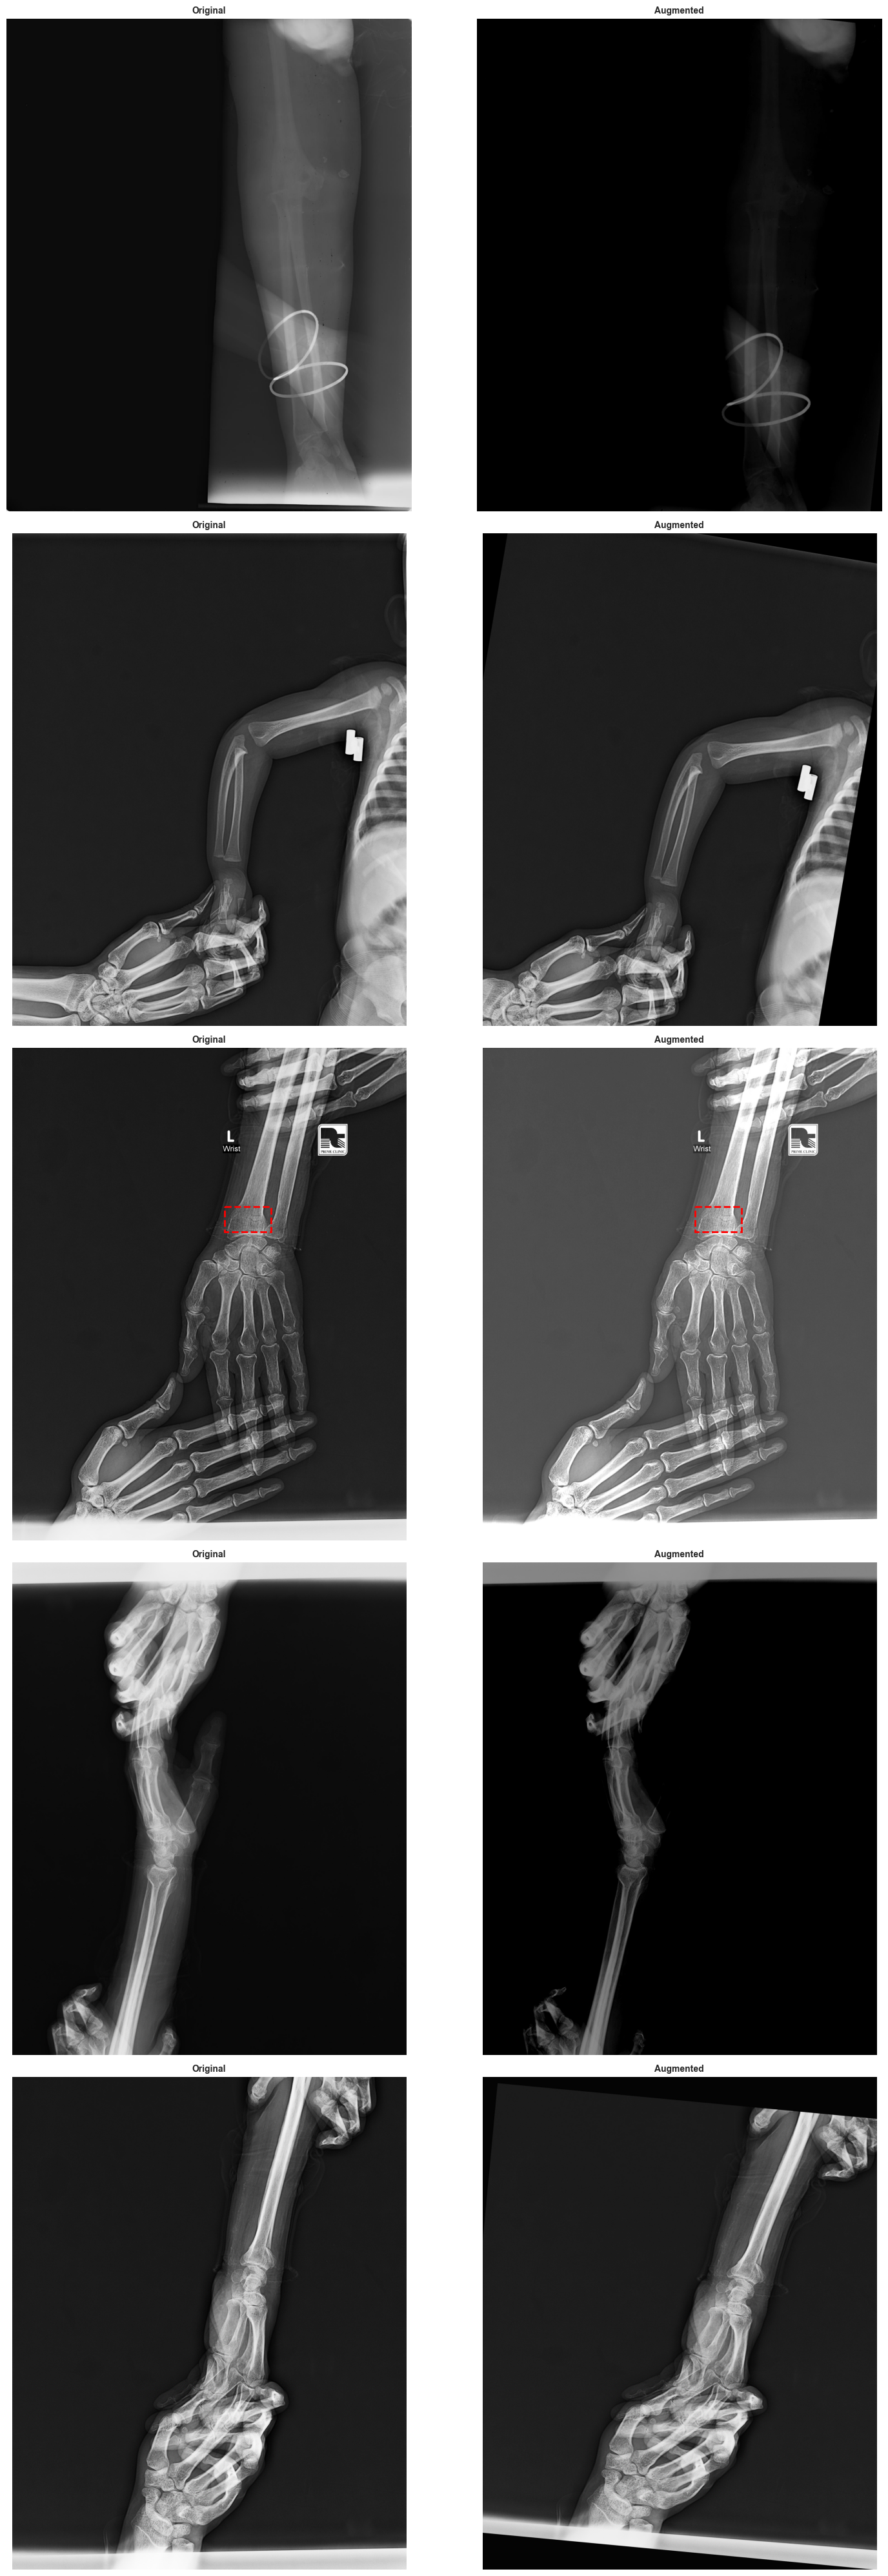


✓ Visualized 5 original vs augmented image pairs
✓ Plot saved to: d:\Project Medical Object Detection\FracAtlas\augmented_pairs_sample.png


In [9]:
def visualize_image_with_bboxes(img_path: Path, label_path: Path, ax, title: str = ""):
    """Visualize an image with bounding boxes."""
    # Load image
    img = cv2.imread(str(img_path))
    if img is None:
        ax.set_title(f"Failed to load: {img_path.name}")
        ax.axis('off')
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]
    
    # Load bounding boxes (handle None label_path for non-fractured images)
    bboxes = []
    if label_path is not None and label_path.exists() and label_path.stat().st_size > 0:
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, cx, cy, w, h = map(float, parts)
                    # Convert YOLO to pixel coordinates
                    x1 = int((cx - w/2) * img_w)
                    y1 = int((cy - h/2) * img_h)
                    x2 = int((cx + w/2) * img_w)
                    y2 = int((cy + h/2) * img_h)
                    bboxes.append([x1, y1, x2, y2])
    
    # Display image
    ax.imshow(img)
    
    # Draw bounding boxes
    for bbox in bboxes:
        rect = patches.Rectangle(
            (bbox[0], bbox[1]), 
            bbox[2] - bbox[0], 
            bbox[3] - bbox[1],
            fill=False, 
            color='red', 
            linewidth=2,
            linestyle='--'
        )
        ax.add_patch(rect)
    
    # Title
    if not title:
        is_aug = "_aug" in img_path.stem
        has_bbox = len(bboxes) > 0
        title = f"{'Augmented' if is_aug else 'Original'} - {'Fractured' if has_bbox else 'Non-fractured'}"
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')


# Sample augmented pairs (original vs augmented)
print("=" * 70)
print("VISUALIZING AUGMENTED IMAGE PAIRS")
print("=" * 70)

train_img_dir = AUGMENTED_DATASET_DIR / "images" / "train"
train_label_dir = AUGMENTED_DATASET_DIR / "labels" / "train"

# Get all images
all_extensions = ["*.png", "*.jpg", "*.jpeg"]
all_imgs = []
for ext in all_extensions:
    all_imgs.extend(list(train_img_dir.glob(ext)))

# Find images with augmentations
augmented_samples = []
for img in all_imgs:
    if "_aug" in img.stem:
        # Find corresponding original
        base_name = img.stem.split("_aug")[0]
        # Try all extensions for the original
        original_img = None
        for ext in all_extensions:
            orig_candidate = train_img_dir / f"{base_name}{ext.replace('*', '')}"
            if orig_candidate.exists():
                original_img = orig_candidate
                break
        
        if original_img and original_img.exists():
            augmented_samples.append((original_img, img))
            if len(augmented_samples) >= 5:
                break

# Create visualization
if len(augmented_samples) > 0:
    fig, axes = plt.subplots(len(augmented_samples), 2, figsize=(16, 8 * len(augmented_samples)))
    
    if len(augmented_samples) == 1:
        axes = np.array([axes])
    
    for i, (orig_img, aug_img) in enumerate(augmented_samples):
        orig_label = train_label_dir / f"{orig_img.stem}.txt"
        aug_label = train_label_dir / f"{aug_img.stem}.txt"
        
        visualize_image_with_bboxes(orig_img, orig_label, axes[i, 0], "Original")
        visualize_image_with_bboxes(aug_img, aug_label, axes[i, 1], "Augmented")
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'augmented_pairs_sample.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Visualized {len(augmented_samples)} original vs augmented image pairs")
    print(f"✓ Plot saved to: {BASE_DIR / 'augmented_pairs_sample.png'}")
else:
    print("\n⚠️ No augmented image pairs found for visualization")
    print("This may happen if augmentation was not applied or failed")


VISUALIZING FRACTURED SAMPLES


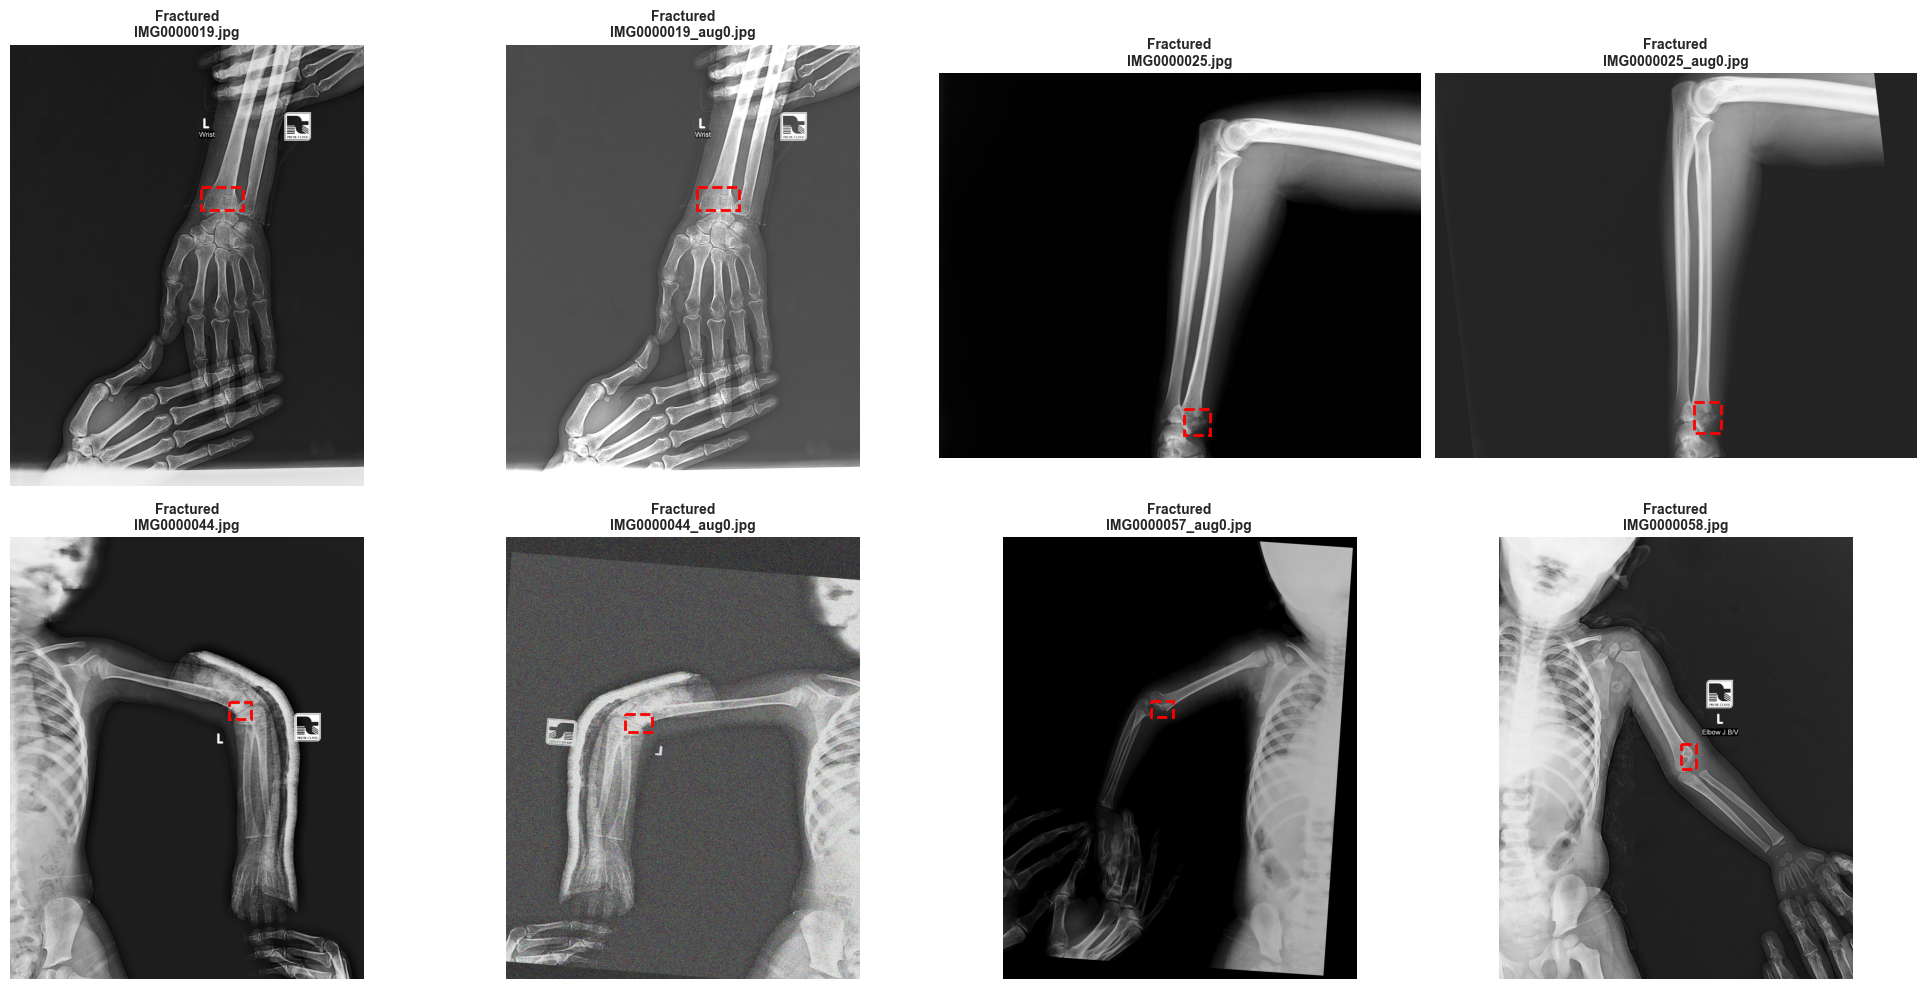


✓ Visualized 8 fractured samples
✓ Plot saved to: d:\Project Medical Object Detection\FracAtlas\fractured_samples.png


In [10]:
# Visualize fractured samples
print("\n" + "=" * 70)
print("VISUALIZING FRACTURED SAMPLES")
print("=" * 70)

fractured_samples = []
for img in all_imgs:
    label_path = train_label_dir / f"{img.stem}.txt"
    if label_path.exists() and label_path.stat().st_size > 0:
        fractured_samples.append(img)
        if len(fractured_samples) >= 8:
            break

if len(fractured_samples) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    for i, img_path in enumerate(fractured_samples):
        label_path = train_label_dir / f"{img_path.stem}.txt"
        visualize_image_with_bboxes(img_path, label_path, axes[i], f"Fractured\n{img_path.name[:20]}")
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'fractured_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Visualized {len(fractured_samples)} fractured samples")
    print(f"✓ Plot saved to: {BASE_DIR / 'fractured_samples.png'}")
else:
    print("\n⚠️ No fractured samples found")


VISUALIZING NON-FRACTURED SAMPLES


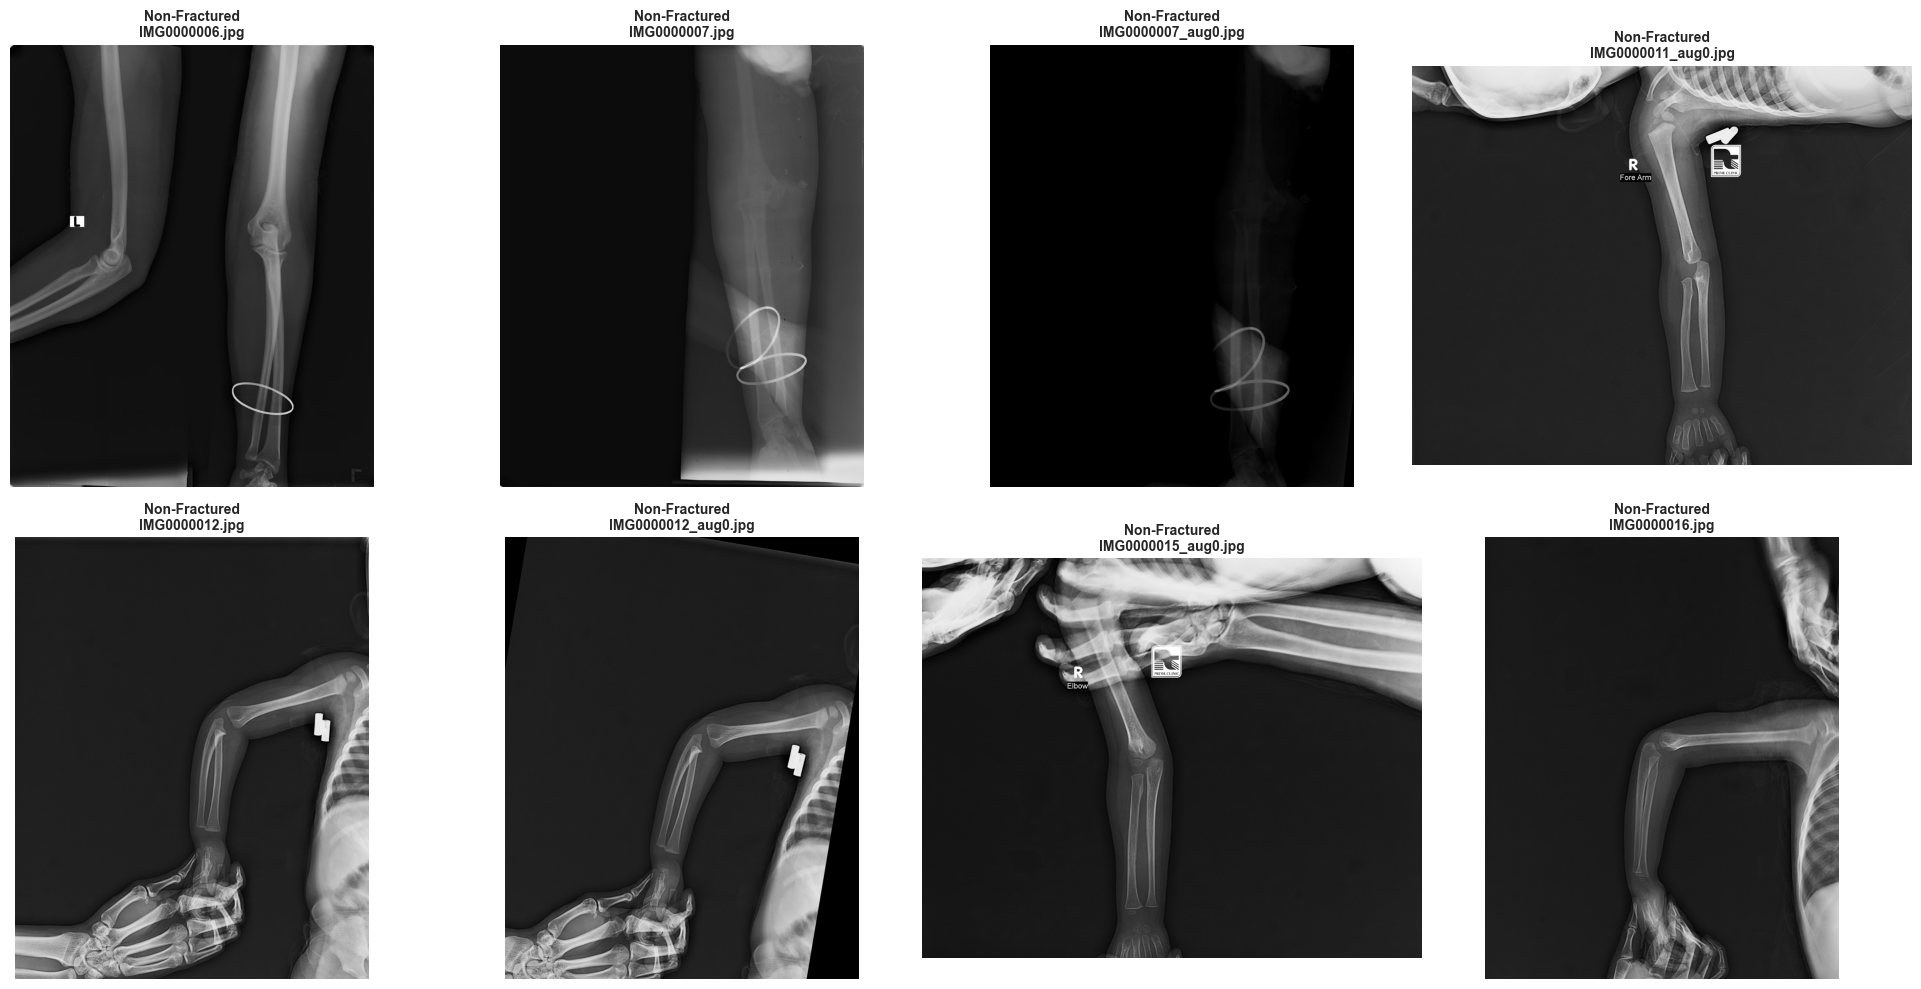


✓ Visualized 8 non-fractured samples
✓ Plot saved to: d:\Project Medical Object Detection\FracAtlas\non_fractured_samples.png


In [11]:
# Visualize non-fractured samples
print("\n" + "=" * 70)
print("VISUALIZING NON-FRACTURED SAMPLES")
print("=" * 70)

non_fractured_samples = []
for img in all_imgs:
    label_path = train_label_dir / f"{img.stem}.txt"
    if label_path.exists() and label_path.stat().st_size == 0:
        non_fractured_samples.append(img)
        if len(non_fractured_samples) >= 8:
            break

if len(non_fractured_samples) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    for i, img_path in enumerate(non_fractured_samples):
        visualize_image_with_bboxes(img_path, None, axes[i], f"Non-Fractured\n{img_path.name[:20]}")
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'non_fractured_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Visualized {len(non_fractured_samples)} non-fractured samples")
    print(f"✓ Plot saved to: {BASE_DIR / 'non_fractured_samples.png'}")
else:
    print("\n⚠️ No non-fractured samples found")

## 6. Augmentation Effectiveness Analysis

In [12]:
# Analyze if augmentation created meaningful variation
print("=" * 70)
print("AUGMENTATION EFFECTIVENESS ANALYSIS")
print("=" * 70)

# Sample some original-augmented pairs and compute differences
def compute_image_difference(img_path1: Path, img_path2: Path):
    """Compute pixel-level difference between two images."""
    img1 = cv2.imread(str(img_path1))
    img2 = cv2.imread(str(img_path2))
    
    if img1 is None or img2 is None:
        return None
    
    # Resize to same size if needed
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
    
    # Compute absolute difference
    diff = cv2.absdiff(img1, img2)
    mean_diff = diff.mean()
    
    return mean_diff

# Sample pairs for analysis
diff_values = []
sample_pairs = augmented_samples[:10] if len(augmented_samples) >= 10 else augmented_samples

print("\nComputing image differences...")
for orig_img, aug_img in tqdm(sample_pairs, desc="Analyzing pairs", leave=False):
    diff = compute_image_difference(orig_img, aug_img)
    if diff is not None:
        diff_values.append(diff)

if len(diff_values) > 0:
    print(f"\nImage Difference Statistics (mean pixel difference):")
    print(f"  Min:  {np.min(diff_values):.2f}")
    print(f"  Max:  {np.max(diff_values):.2f}")
    print(f"  Mean: {np.mean(diff_values):.2f}")
    print(f"  Std:  {np.std(diff_values):.2f}")
    
    # Interpret
    mean_diff = np.mean(diff_values)
    if mean_diff < 5:
        print(f"\n⚠️  Low variation - augmentation may be too conservative")
    elif mean_diff < 30:
        print(f"\n✅ Good variation - augmentation is effective")
    else:
        print(f"\n⚠️  High variation - augmentation may be too aggressive")
else:
    print("\n⚠️  Could not compute differences")

AUGMENTATION EFFECTIVENESS ANALYSIS

Computing image differences...



Image Difference Statistics (mean pixel difference):
  Min:  27.73
  Max:  48.30
  Mean: 35.22
  Std:  7.52

⚠️  High variation - augmentation may be too aggressive



AUGMENTATION SUMMARY

Train Split:
  Original images:     1094
  Augmented versions:  1059
  Total:               2153
  Augmentation ratio:  0.97x

Overall Dataset:
  Original images:     1538
  Augmented versions:  1538
  Total:               3076
  Augmentation ratio:  1.00x


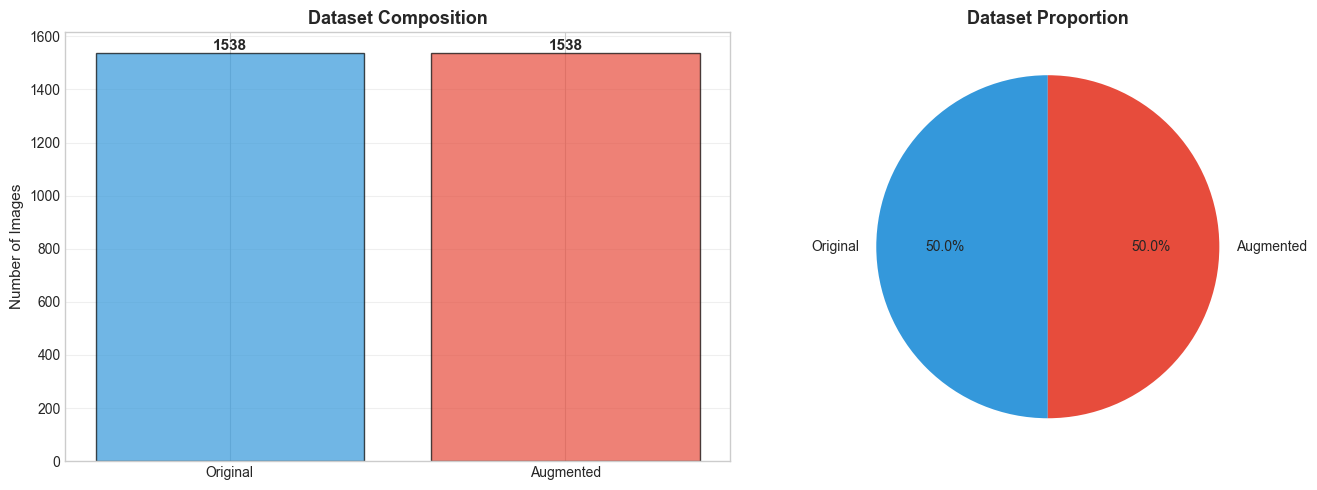


✓ Plot saved to: d:\Project Medical Object Detection\FracAtlas\augmentation_summary.png


In [13]:
# Augmentation summary
print("\n" + "=" * 70)
print("AUGMENTATION SUMMARY")
print("=" * 70)

# Count augmented vs original
all_imgs_list = list(train_img_dir.glob("*.jpg")) + list(train_img_dir.glob("*.png"))
original_count = sum(1 for img in all_imgs_list if "_aug" not in img.stem)
augmented_count = sum(1 for img in all_imgs_list if "_aug" in img.stem)

print(f"\nTrain Split:")
print(f"  Original images:     {original_count}")
print(f"  Augmented versions:  {augmented_count}")
print(f"  Total:               {len(all_imgs_list)}")
print(f"  Augmentation ratio:  {augmented_count/original_count:.2f}x" if original_count > 0 else "  N/A")

# Overall dataset
total_original = 0
total_augmented = 0

for split in ['train', 'val', 'test']:
    img_dir = AUGMENTED_DATASET_DIR / 'images' / split
    if not img_dir.exists():
        continue
    
    imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    orig = sum(1 for img in imgs if "_aug" not in img.stem)
    aug = sum(1 for img in imgs if "_aug" in img.stem)
    total_original += orig
    total_augmented += aug

print(f"\nOverall Dataset:")
print(f"  Original images:     {total_original}")
print(f"  Augmented versions:  {total_augmented}")
print(f"  Total:               {total_original + total_augmented}")
print(f"  Augmentation ratio:  {total_augmented/total_original:.2f}x" if total_original > 0 else "  N/A")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
categories = ['Original', 'Augmented']
counts = [total_original, total_augmented]
colors = ['#3498db', '#e74c3c']

bars = axes[0].bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Number of Images', fontsize=11)
axes[0].set_title('Dataset Composition', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Dataset Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(BASE_DIR / 'augmentation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Plot saved to: {BASE_DIR / 'augmentation_summary.png'}")

## 7. Summary & Recommendations

In [14]:
print("\n" + "=" * 80)
print(" " * 20 + "DATASET EVALUATION SUMMARY")
print("=" * 80)

# Dataset size
print(f"\n📊 DATASET SIZE:")
print(f"   Total images:        {total_images}")
print(f"   - Fractured:         {total_fractured} ({100*total_fractured/total_images:.1f}%)")
print(f"   - Non-fractured:     {total_non_fractured} ({100*total_non_fractured/total_images:.1f}%)")
print(f"   Ratio (Non-Frac/Frac): {total_non_fractured/total_fractured:.2f}:1")

# Label quality
total_label_issues = sum(len(issues['missing_labels']) + len(issues['invalid_format']) + 
                         len(issues['invalid_bbox']) + len(issues['corrupt_files']) 
                         for issues in all_issues.values())

print(f"\n🏷️  LABEL QUALITY:")
print(f"   Total issues:        {total_label_issues}")
if total_label_issues == 0:
    print(f"   Status:              ✅ ALL VALID")
else:
    print(f"   Status:              ⚠️  ISSUES DETECTED")

# Image quality
total_img_issues = sum(len(issues['corrupt']) for issues in all_img_issues.values())

print(f"\n🖼️  IMAGE QUALITY:")
print(f"   Corrupt images:      {total_img_issues}")
if total_img_issues == 0:
    print(f"   Status:              ✅ ALL VALID")
else:
    print(f"   Status:              ⚠️  CORRUPT IMAGES FOUND")

# Augmentation
print(f"\n🔄 AUGMENTATION:")
print(f"   Original images:     {total_original}")
print(f"   Augmented versions:  {total_augmented}")
print(f"   Augmentation ratio:  {total_augmented/total_original:.2f}x" if total_original > 0 else "   N/A")

# Go/No-Go decision
print("\n" + "=" * 80)
print(" " * 25 + "GO / NO-GO DECISION")
print("=" * 80)

issues_list = []
if total_label_issues > 0:
    issues_list.append("Label quality issues detected")
if total_img_issues > 0:
    issues_list.append("Corrupt images detected")
if total_images < 1000:
    issues_list.append("Dataset size is small (<1000 images)")
if total_fractured / total_images < 0.2:
    issues_list.append("Class imbalance is severe (<20% fractured)")

if len(issues_list) == 0:
    print("\n✅ GO - Dataset is ready for training!")
    print("\nNo critical issues found. You can proceed to Notebook 02 (Training).")
else:
    print("\n⚠️  NO-GO - Issues need to be addressed first:")
    for i, issue in enumerate(issues_list, 1):
        print(f"   {i}. {issue}")
    print("\nPlease fix these issues before proceeding to training.")

# Recommendations
print("\n" + "=" * 80)
print(" " * 20 + "RECOMMENDATIONS FOR TRAINING")
print("=" * 80)

print("\n📌 Suggested Training Configuration:")
print(f"   • Model: yolo12m.pt (or yolo8s.pt for faster experiments)")
print(f"   • Image size: 1024px (X-rays have fine fracture details)")
print(f"   • Epochs: 100 (with early stopping patience=20)")
print(f"   • Batch size: 4 (reduce to 2 if CUDA OOM)")
print(f"   • Workers: 4")
print(f"   • Augmentation: Conservative (degrees=10, flipud=0, fliplr=0.5)")
print(f"   • Optimizer: Auto (will select best)")
print(f"   • Learning rate: 0.01 (with cosine decay)")

print("\n📌 Next Steps:")
if len(issues_list) == 0:
    print("   1. ✅ Review the visualizations above")
    print("   2. ✅ Open Notebook 02 (02_training_yolov8.ipynb)")
    print("   3. ✅ Update YAML_PATH to point to 'fracatlas_hand_augmented.yaml'")
    print("   4. ✅ Run training")
    print("   5. ✅ Monitor training metrics")
    print("   6. ✅ Evaluate model on test set")
else:
    print("   1. ⚠️  Fix the issues listed above")
    print("   2. ⚠️  Re-run this evaluation notebook")
    print("   3. ✅ Once GO, proceed to Notebook 02")

print("\n" + "=" * 80)


                    DATASET EVALUATION SUMMARY

📊 DATASET SIZE:
   Total images:        3076
   - Fractured:         876 (28.5%)
   - Non-fractured:     2200 (71.5%)
   Ratio (Non-Frac/Frac): 2.51:1

🏷️  LABEL QUALITY:
   Total issues:        0
   Status:              ✅ ALL VALID

🖼️  IMAGE QUALITY:
   Corrupt images:      0
   Status:              ✅ ALL VALID

🔄 AUGMENTATION:
   Original images:     1538
   Augmented versions:  1538
   Augmentation ratio:  1.00x

                         GO / NO-GO DECISION

✅ GO - Dataset is ready for training!

No critical issues found. You can proceed to Notebook 02 (Training).

                    RECOMMENDATIONS FOR TRAINING

📌 Suggested Training Configuration:
   • Model: yolo12m.pt (or yolo8s.pt for faster experiments)
   • Image size: 1024px (X-rays have fine fracture details)
   • Epochs: 100 (with early stopping patience=20)
   • Batch size: 4 (reduce to 2 if CUDA OOM)
   • Workers: 4
   • Augmentation: Conservative (degrees=10, flipud=0, f